# 02. Analisis Exploratorio de Datos (EDA)

Exploracion exhaustiva de los datos de Instagram, TikTok y Trustpilot para Lululemon.

**Secciones:**
1. Vision general de los datos
2. Analisis de engagement por plataforma
3. Tendencias temporales
4. Analisis de contenido (hashtags, captions, creators)
5. Distribuciones geograficas
6. Correlaciones

In [1]:
import sys
sys.path.insert(0, "../../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from plotting import setup_style, save_fig, COLORS, PLATFORM_COLORS
setup_style()

DATA = "../../datos/clean"

tp = pd.read_csv(f"{DATA}/trustpilot_all.csv", parse_dates=["published_date"])
ig = pd.read_csv(f"{DATA}/ig_publicaciones.csv", parse_dates=["timestamp"])
ig_com = pd.read_csv(f"{DATA}/ig_comentarios.csv", parse_dates=["timestamp"])
tk = pd.read_csv(f"{DATA}/tiktok_videos.csv", parse_dates=["uploaded_at"])
tk_com = pd.read_csv(f"{DATA}/tiktok_comentarios.csv", parse_dates=["timestamp"])

print(f"Trustpilot: {len(tp)} | IG posts: {len(ig)} | IG comments: {len(ig_com)}")
print(f"TikTok videos: {len(tk)} | TikTok comments: {len(tk_com)}")

Trustpilot: 383 | IG posts: 577 | IG comments: 1266
TikTok videos: 295 | TikTok comments: 1056


## 1. Vision general

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/eda_overview.png


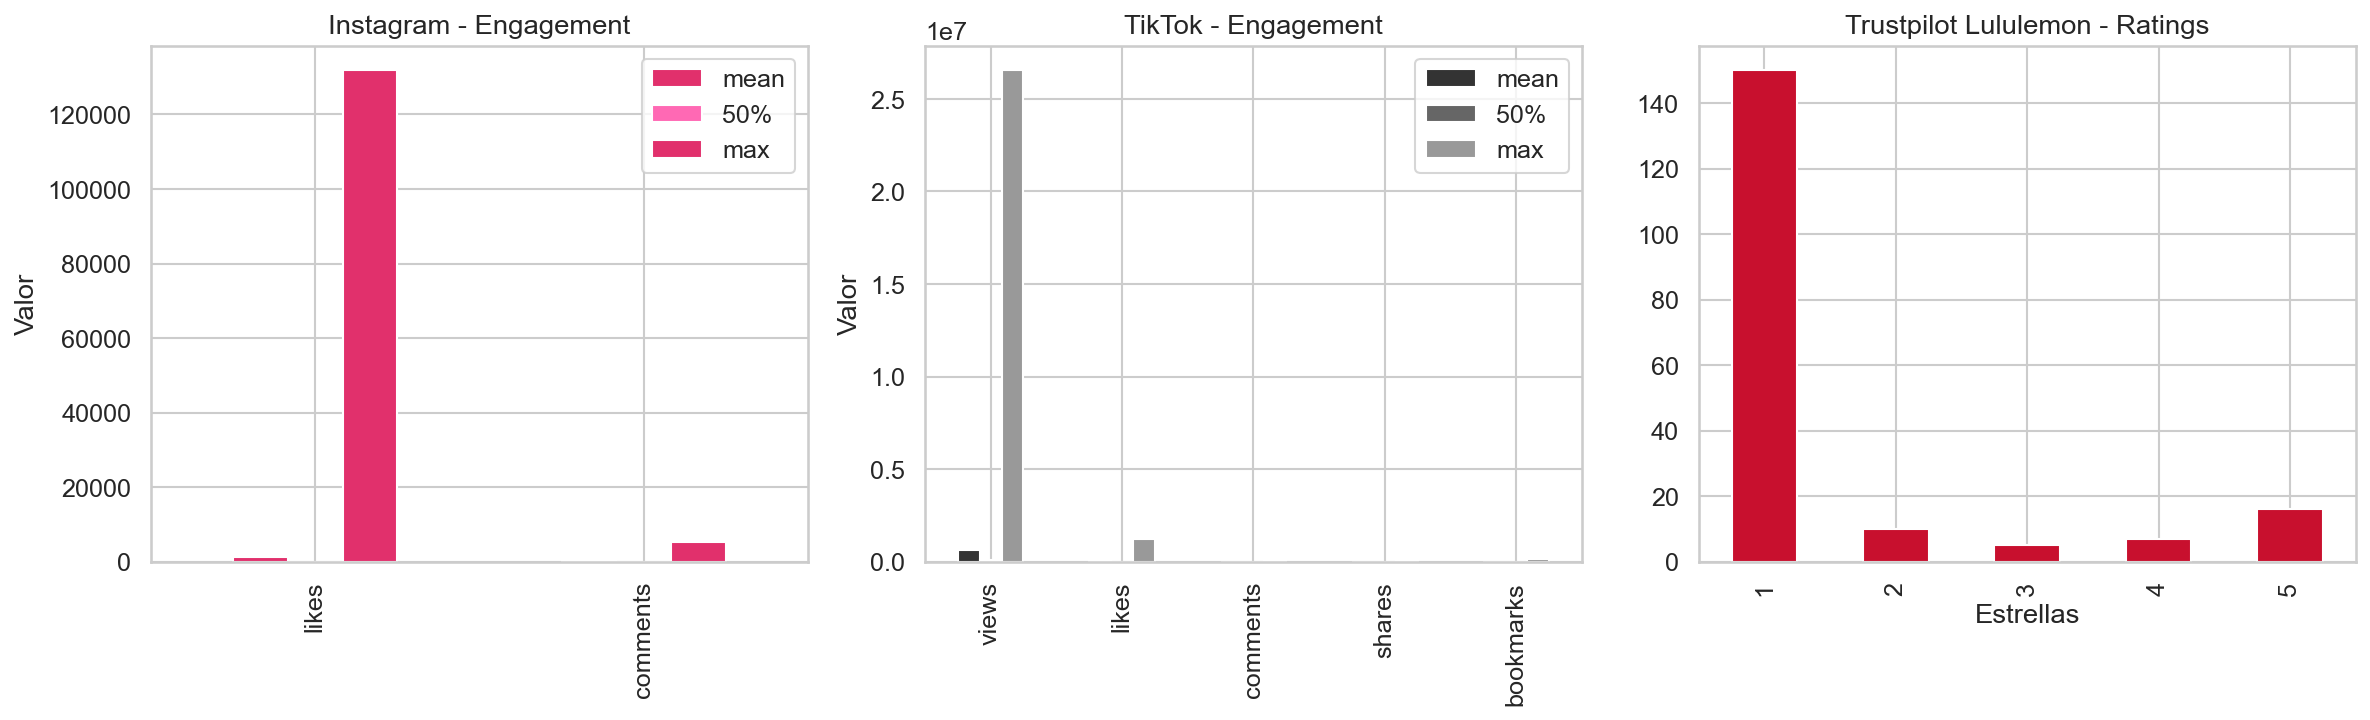

In [2]:
# Descripcion estadistica por plataforma
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# IG engagement
ig[["likes", "comments"]].describe().T[["mean", "50%", "max"]].plot(
    kind="bar", ax=axes[0], color=[PLATFORM_COLORS["instagram"], "#FF69B4"]
)
axes[0].set_title("Instagram - Engagement")
axes[0].set_ylabel("Valor")

# TikTok engagement
tk[["views", "likes", "comments", "shares", "bookmarks"]].describe().T[["mean", "50%", "max"]].plot(
    kind="bar", ax=axes[1], color=["#333", "#666", "#999", "#BBB", "#DDD"]
)
axes[1].set_title("TikTok - Engagement")
axes[1].set_ylabel("Valor")

# Trustpilot ratings
tp[tp["brand"]=="Lululemon"]["rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[2], color=COLORS["lululemon_red"]
)
axes[2].set_title("Trustpilot Lululemon - Ratings")
axes[2].set_xlabel("Estrellas")

plt.tight_layout()
save_fig(fig, "eda_overview")
plt.show()

## 2. Distribuciones de engagement

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/eda_distribuciones_engagement.png


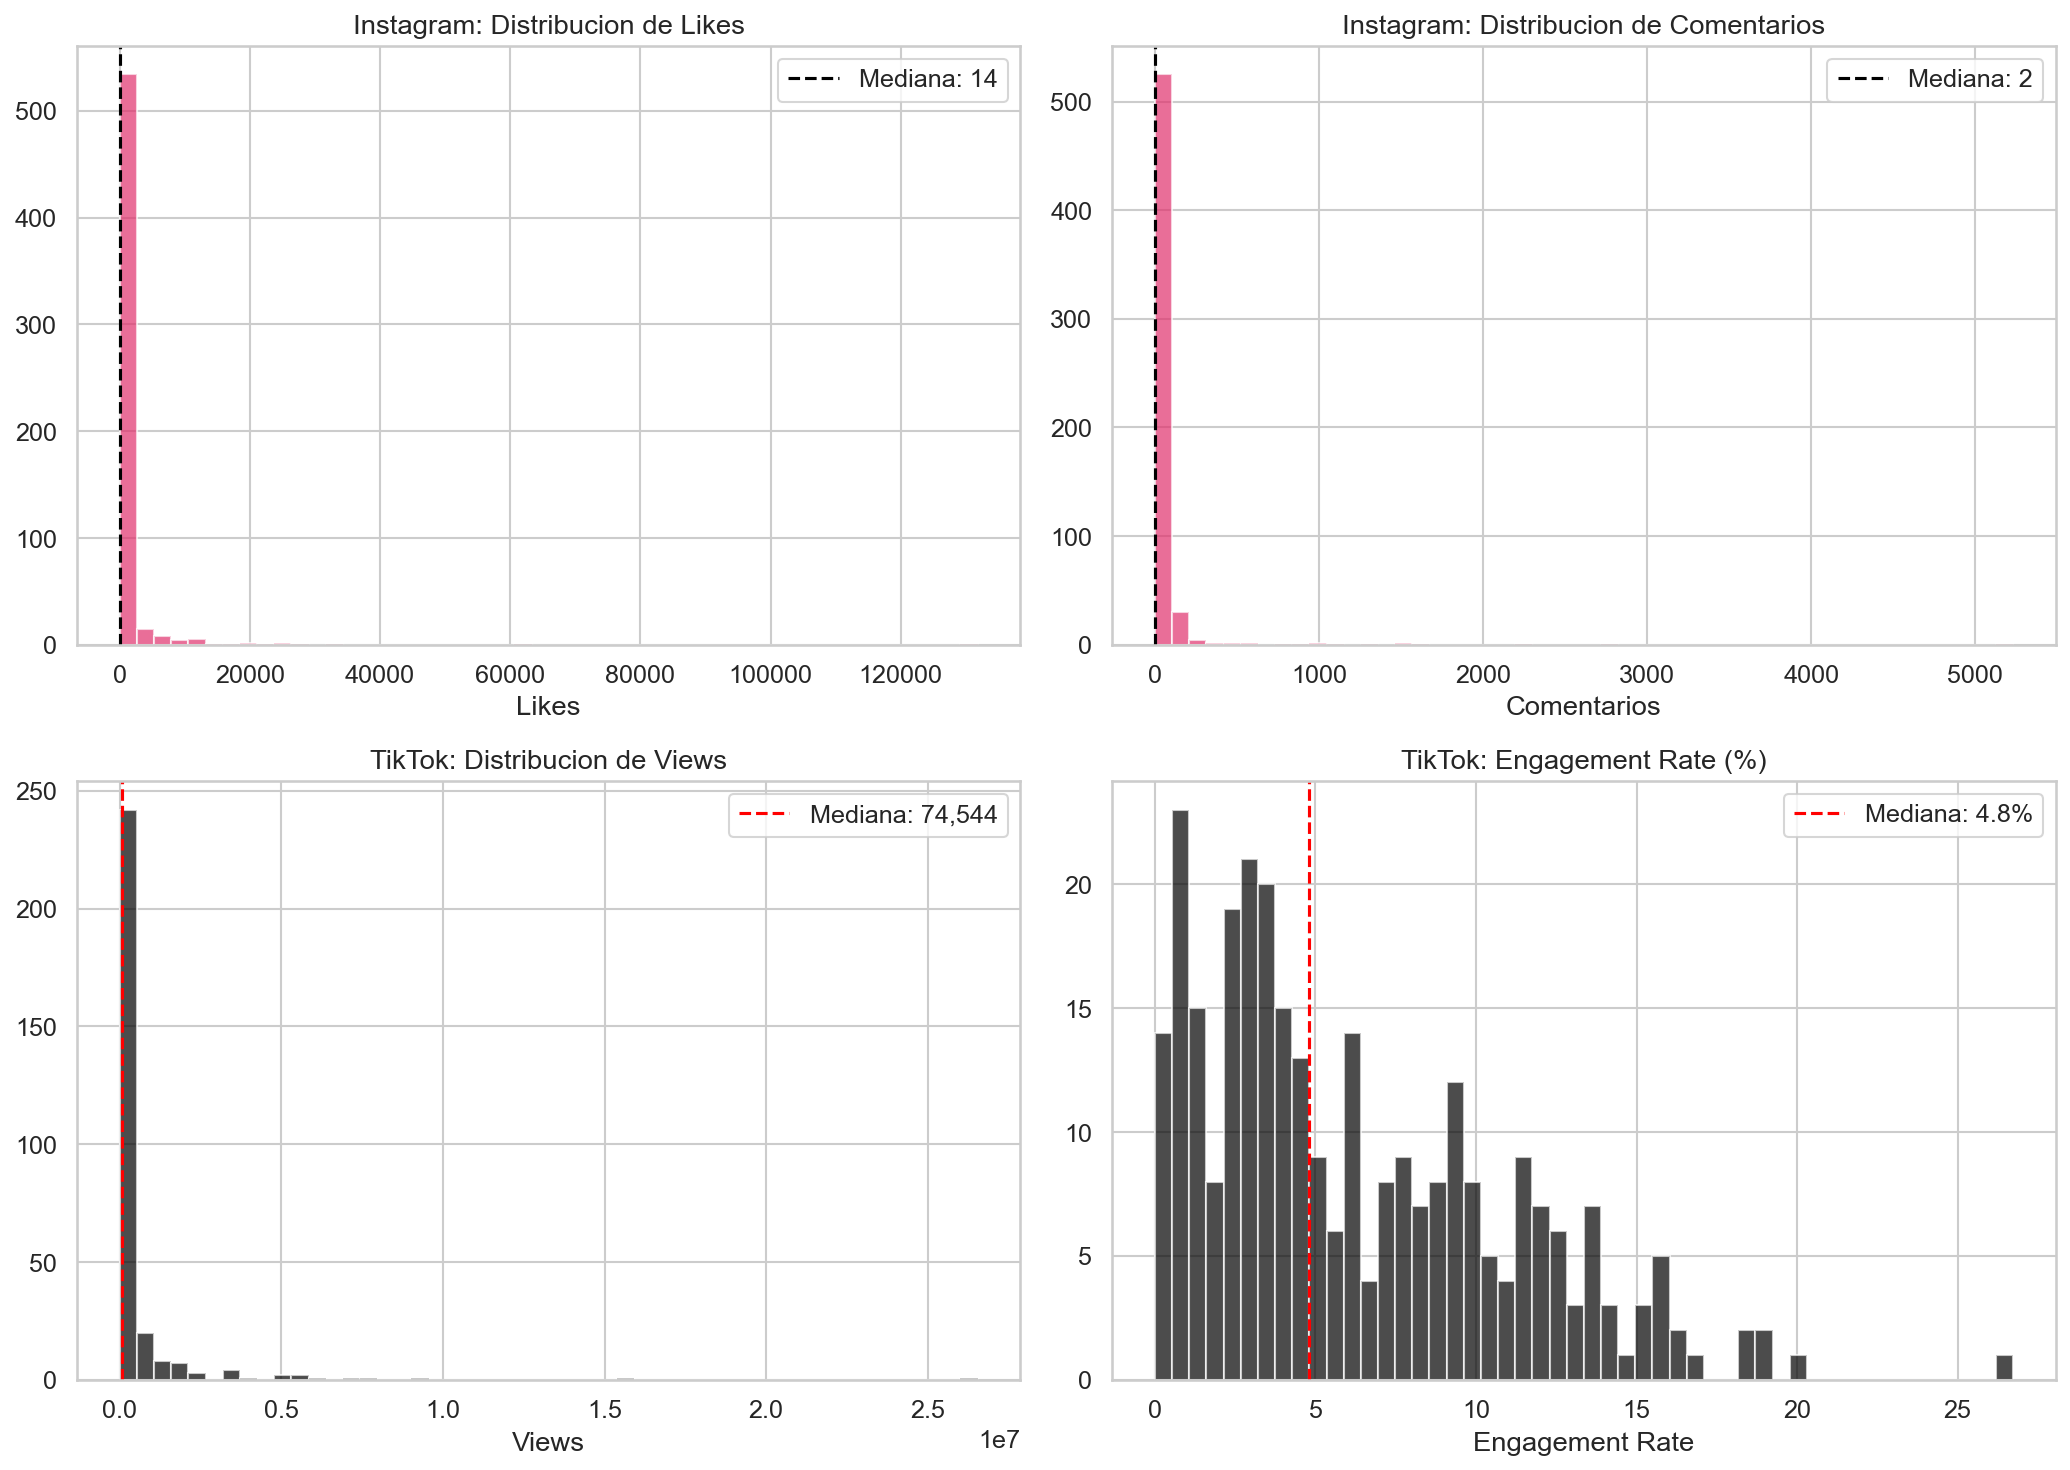

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# IG likes distribution
axes[0,0].hist(ig["likes"], bins=50, color=PLATFORM_COLORS["instagram"], alpha=0.7, edgecolor="white")
axes[0,0].set_title("Instagram: Distribucion de Likes")
axes[0,0].set_xlabel("Likes")
axes[0,0].axvline(ig["likes"].median(), color="black", linestyle="--", label=f"Mediana: {ig['likes'].median():,.0f}")
axes[0,0].legend()

# IG comments distribution
axes[0,1].hist(ig["comments"], bins=50, color=PLATFORM_COLORS["instagram"], alpha=0.7, edgecolor="white")
axes[0,1].set_title("Instagram: Distribucion de Comentarios")
axes[0,1].set_xlabel("Comentarios")
axes[0,1].axvline(ig["comments"].median(), color="black", linestyle="--", label=f"Mediana: {ig['comments'].median():,.0f}")
axes[0,1].legend()

# TikTok views distribution
axes[1,0].hist(tk["views"], bins=50, color=PLATFORM_COLORS["tiktok"], alpha=0.7, edgecolor="white")
axes[1,0].set_title("TikTok: Distribucion de Views")
axes[1,0].set_xlabel("Views")
axes[1,0].axvline(tk["views"].median(), color="red", linestyle="--", label=f"Mediana: {tk['views'].median():,.0f}")
axes[1,0].legend()

# TikTok engagement rate
axes[1,1].hist(tk["engagement_rate"].dropna(), bins=50, color=PLATFORM_COLORS["tiktok"], alpha=0.7, edgecolor="white")
axes[1,1].set_title("TikTok: Engagement Rate (%)")
axes[1,1].set_xlabel("Engagement Rate")
axes[1,1].axvline(tk["engagement_rate"].median(), color="red", linestyle="--", label=f"Mediana: {tk['engagement_rate'].median():.1f}%")
axes[1,1].legend()

plt.tight_layout()
save_fig(fig, "eda_distribuciones_engagement")
plt.show()

## 3. Tendencias temporales

/var/folders/hw/k9dl2bvx033g270sxxkmnwlw0000gn/T/ipykernel_92832/2534902320.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tk_monthly = tk.groupby(tk["uploaded_at"].dt.to_period("M")).agg(


Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/eda_tendencias_temporales.png


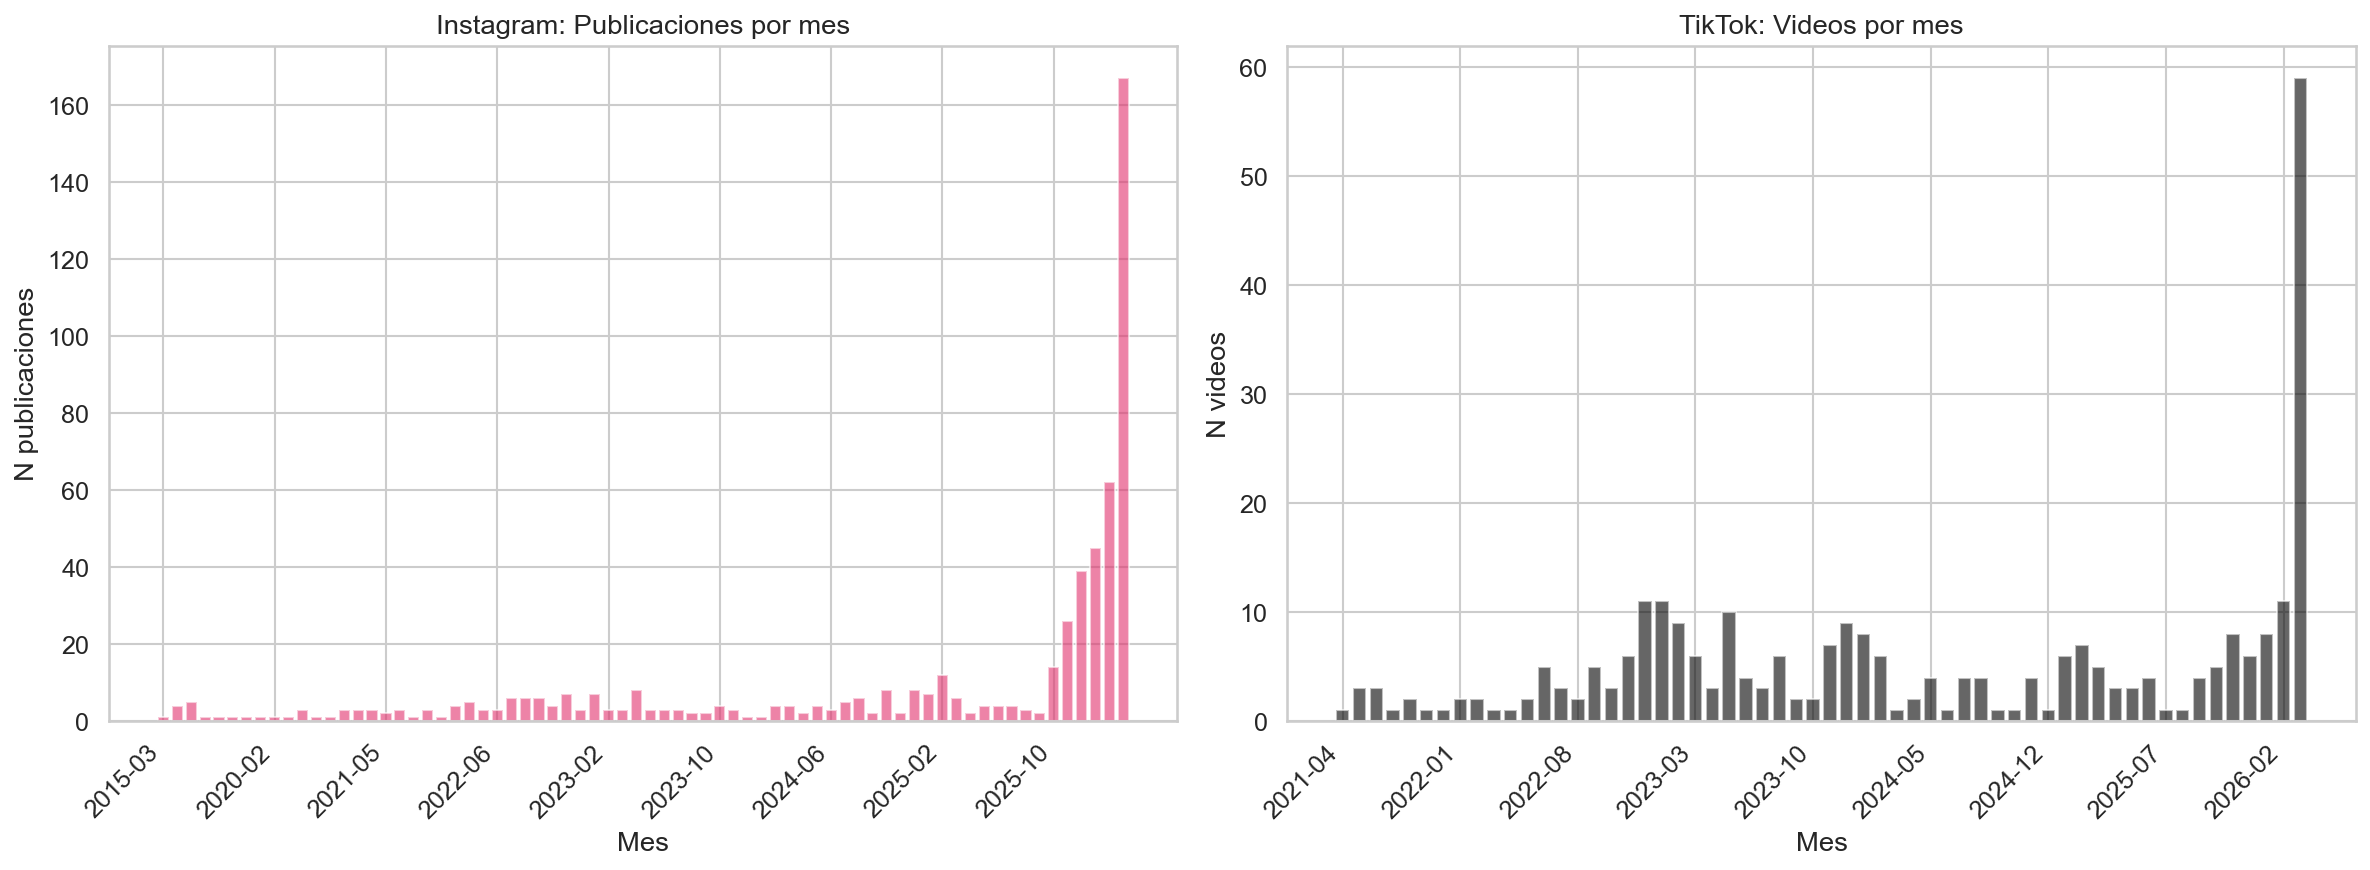

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# IG por mes
ig_monthly = ig.groupby(ig["timestamp"].dt.to_period("M")).agg(
    n_posts=("url", "count"),
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"),
).reset_index()
ig_monthly["timestamp"] = ig_monthly["timestamp"].astype(str)

ax1 = axes[0]
ax1.bar(range(len(ig_monthly)), ig_monthly["n_posts"], color=PLATFORM_COLORS["instagram"], alpha=0.6)
ax1.set_title("Instagram: Publicaciones por mes")
ax1.set_xlabel("Mes")
ax1.set_ylabel("N publicaciones")
ax1.set_xticks(range(0, len(ig_monthly), max(1, len(ig_monthly)//8)))
ax1.set_xticklabels(ig_monthly["timestamp"].iloc[::max(1, len(ig_monthly)//8)], rotation=45, ha="right")

# TikTok por mes
tk_monthly = tk.groupby(tk["uploaded_at"].dt.to_period("M")).agg(
    n_videos=("id", "count"),
    avg_views=("views", "mean"),
).reset_index()
tk_monthly["uploaded_at"] = tk_monthly["uploaded_at"].astype(str)

ax2 = axes[1]
ax2.bar(range(len(tk_monthly)), tk_monthly["n_videos"], color=PLATFORM_COLORS["tiktok"], alpha=0.6)
ax2.set_title("TikTok: Videos por mes")
ax2.set_xlabel("Mes")
ax2.set_ylabel("N videos")
ax2.set_xticks(range(0, len(tk_monthly), max(1, len(tk_monthly)//8)))
ax2.set_xticklabels(tk_monthly["uploaded_at"].iloc[::max(1, len(tk_monthly)//8)], rotation=45, ha="right")

plt.tight_layout()
save_fig(fig, "eda_tendencias_temporales")
plt.show()

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/eda_evolucion_engagement.png


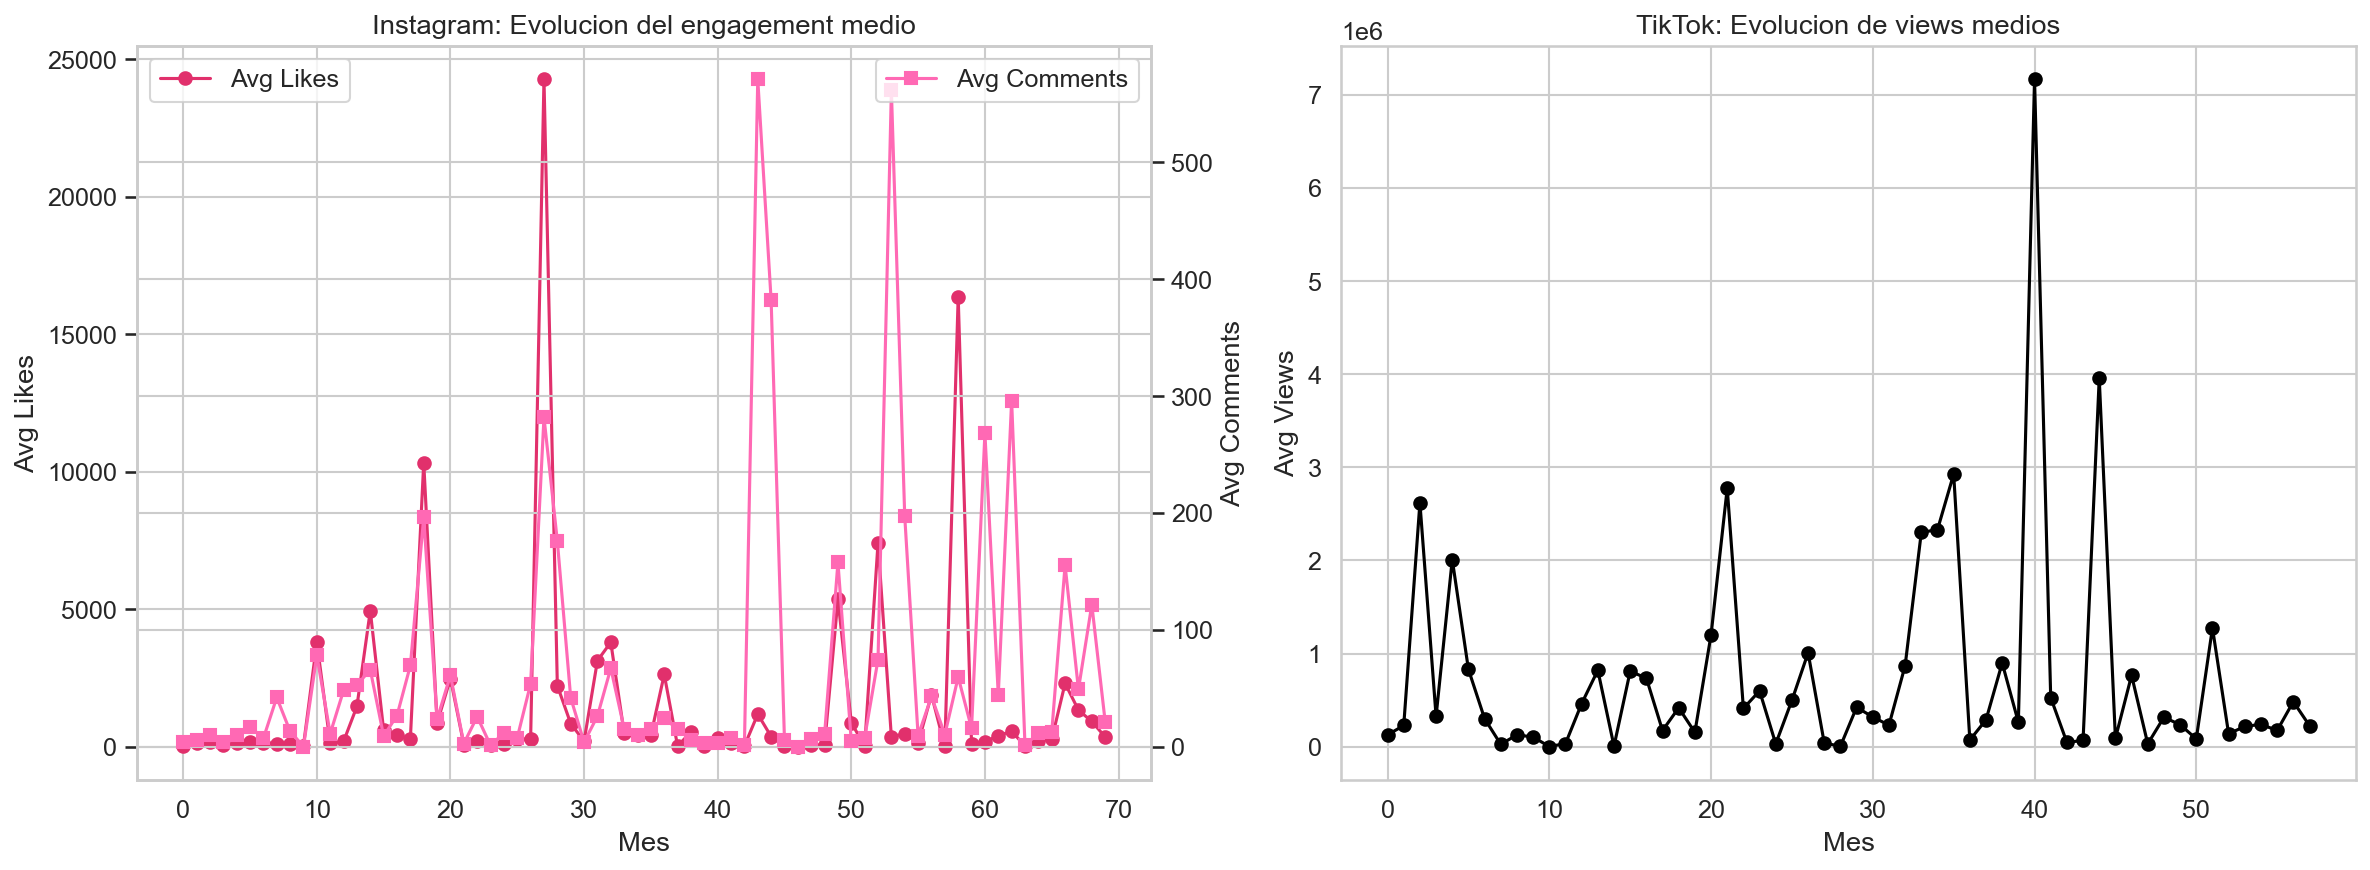

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# IG engagement evolution
ax1 = axes[0]
ax1.plot(range(len(ig_monthly)), ig_monthly["avg_likes"], marker="o", color=PLATFORM_COLORS["instagram"], label="Avg Likes")
ax1_2 = ax1.twinx()
ax1_2.plot(range(len(ig_monthly)), ig_monthly["avg_comments"], marker="s", color="#FF69B4", label="Avg Comments")
ax1.set_title("Instagram: Evolucion del engagement medio")
ax1.set_xlabel("Mes")
ax1.set_ylabel("Avg Likes")
ax1_2.set_ylabel("Avg Comments")
ax1.legend(loc="upper left")
ax1_2.legend(loc="upper right")

# TikTok views evolution
ax2 = axes[1]
ax2.plot(range(len(tk_monthly)), tk_monthly["avg_views"], marker="o", color=PLATFORM_COLORS["tiktok"])
ax2.set_title("TikTok: Evolucion de views medios")
ax2.set_xlabel("Mes")
ax2.set_ylabel("Avg Views")

plt.tight_layout()
save_fig(fig, "eda_evolucion_engagement")
plt.show()

## 4. Analisis de contenido

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/eda_hashtags_instagram.png


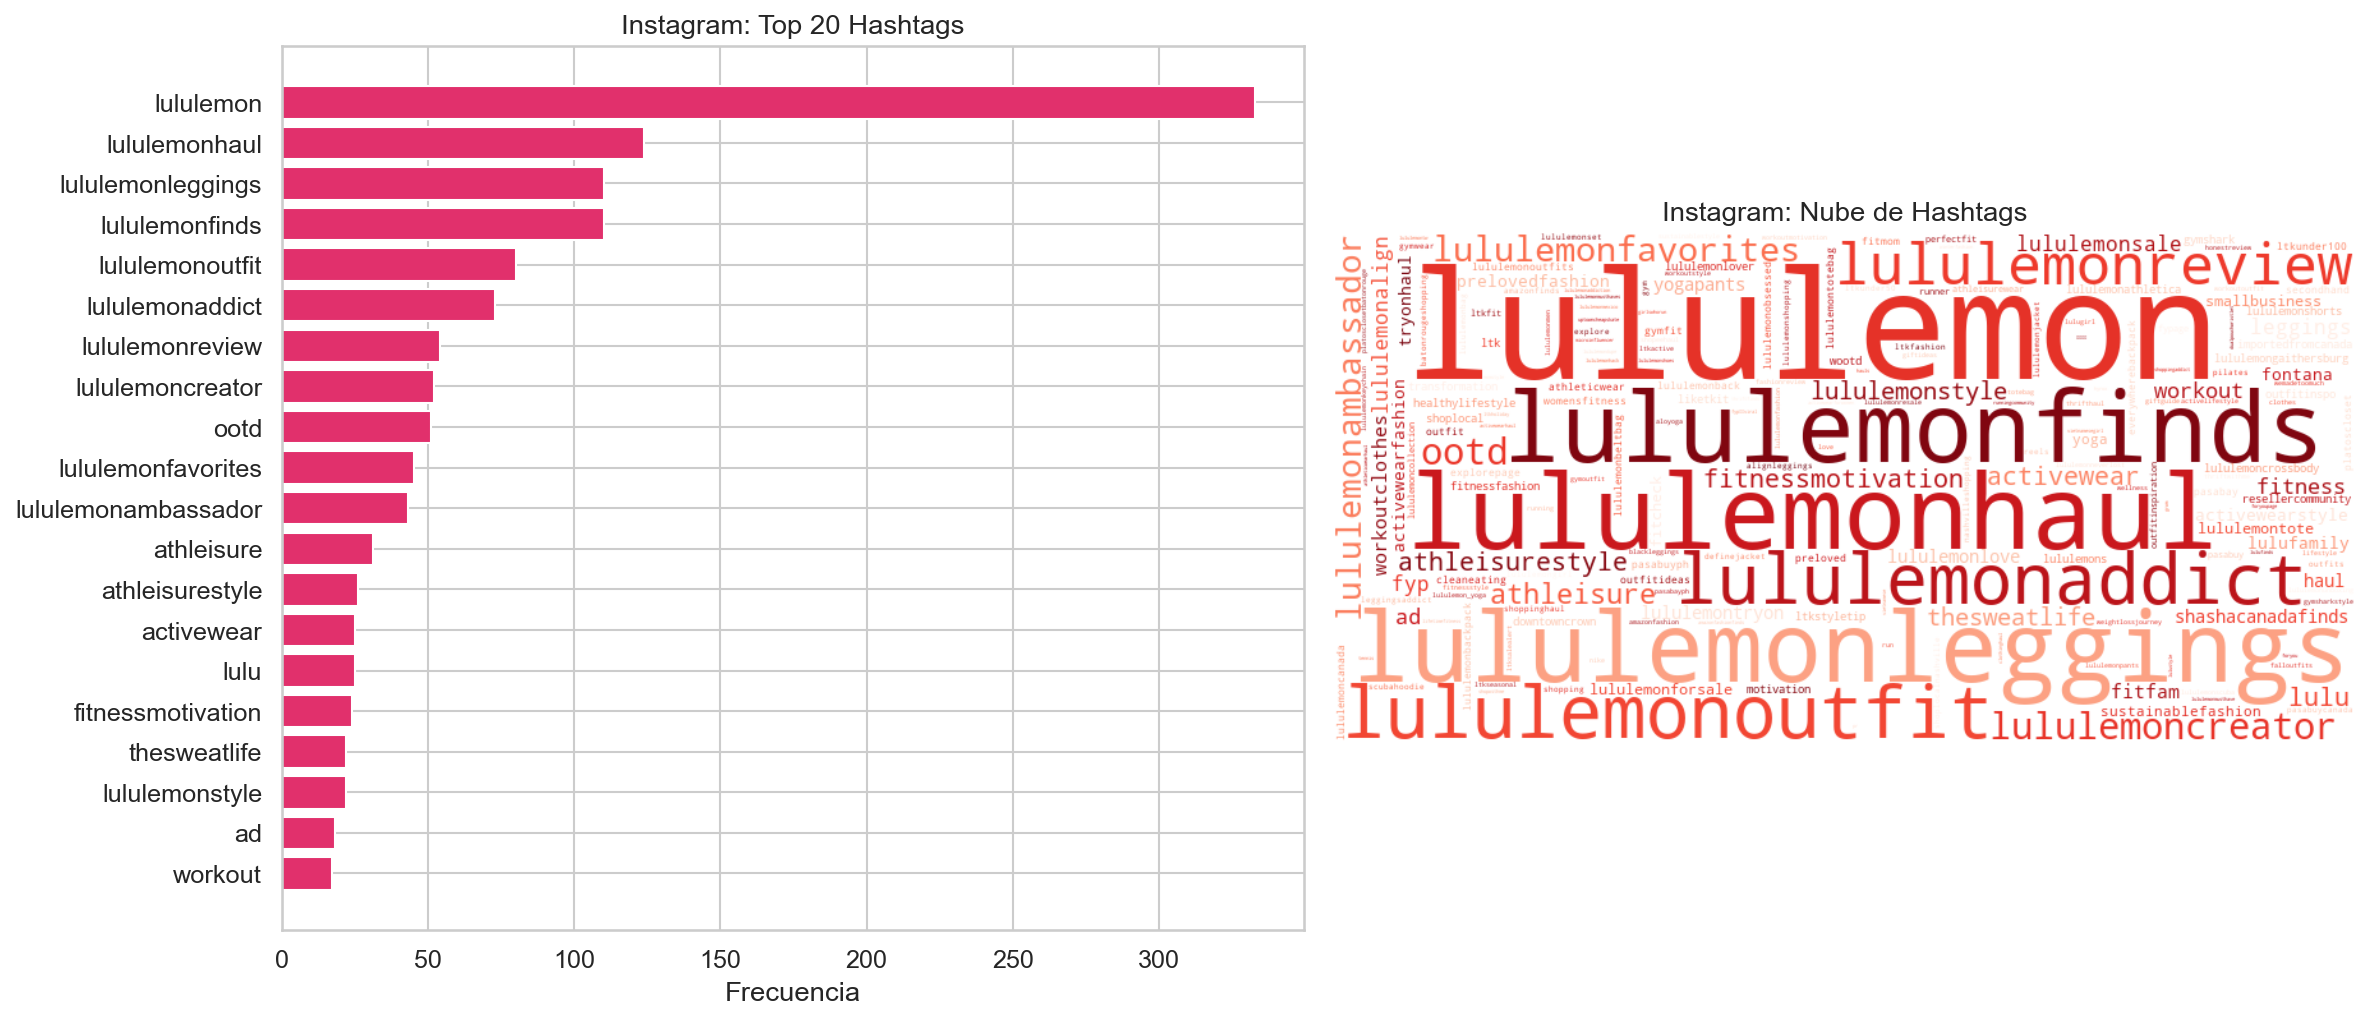

In [6]:
import ast
from wordcloud import WordCloud

# Extraer hashtags de IG
def extract_hashtags(col):
    all_tags = []
    for val in col.dropna():
        try:
            tags = ast.literal_eval(val) if isinstance(val, str) else val
            if isinstance(tags, list):
                all_tags.extend([str(t).lower().strip() for t in tags])
        except:
            pass
    return Counter(all_tags)

ig_hashtags = extract_hashtags(ig["hashtags"])

# Top 20 hashtags IG
top_ig_tags = pd.DataFrame(ig_hashtags.most_common(20), columns=["hashtag", "count"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Barplot
axes[0].barh(top_ig_tags["hashtag"][::-1], top_ig_tags["count"][::-1], color=PLATFORM_COLORS["instagram"])
axes[0].set_title("Instagram: Top 20 Hashtags")
axes[0].set_xlabel("Frecuencia")

# Wordcloud
wc = WordCloud(width=800, height=400, background_color="white", colormap="Reds").generate_from_frequencies(ig_hashtags)
axes[1].imshow(wc, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Instagram: Nube de Hashtags")

plt.tight_layout()
save_fig(fig, "eda_hashtags_instagram")
plt.show()

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/eda_top_creators.png


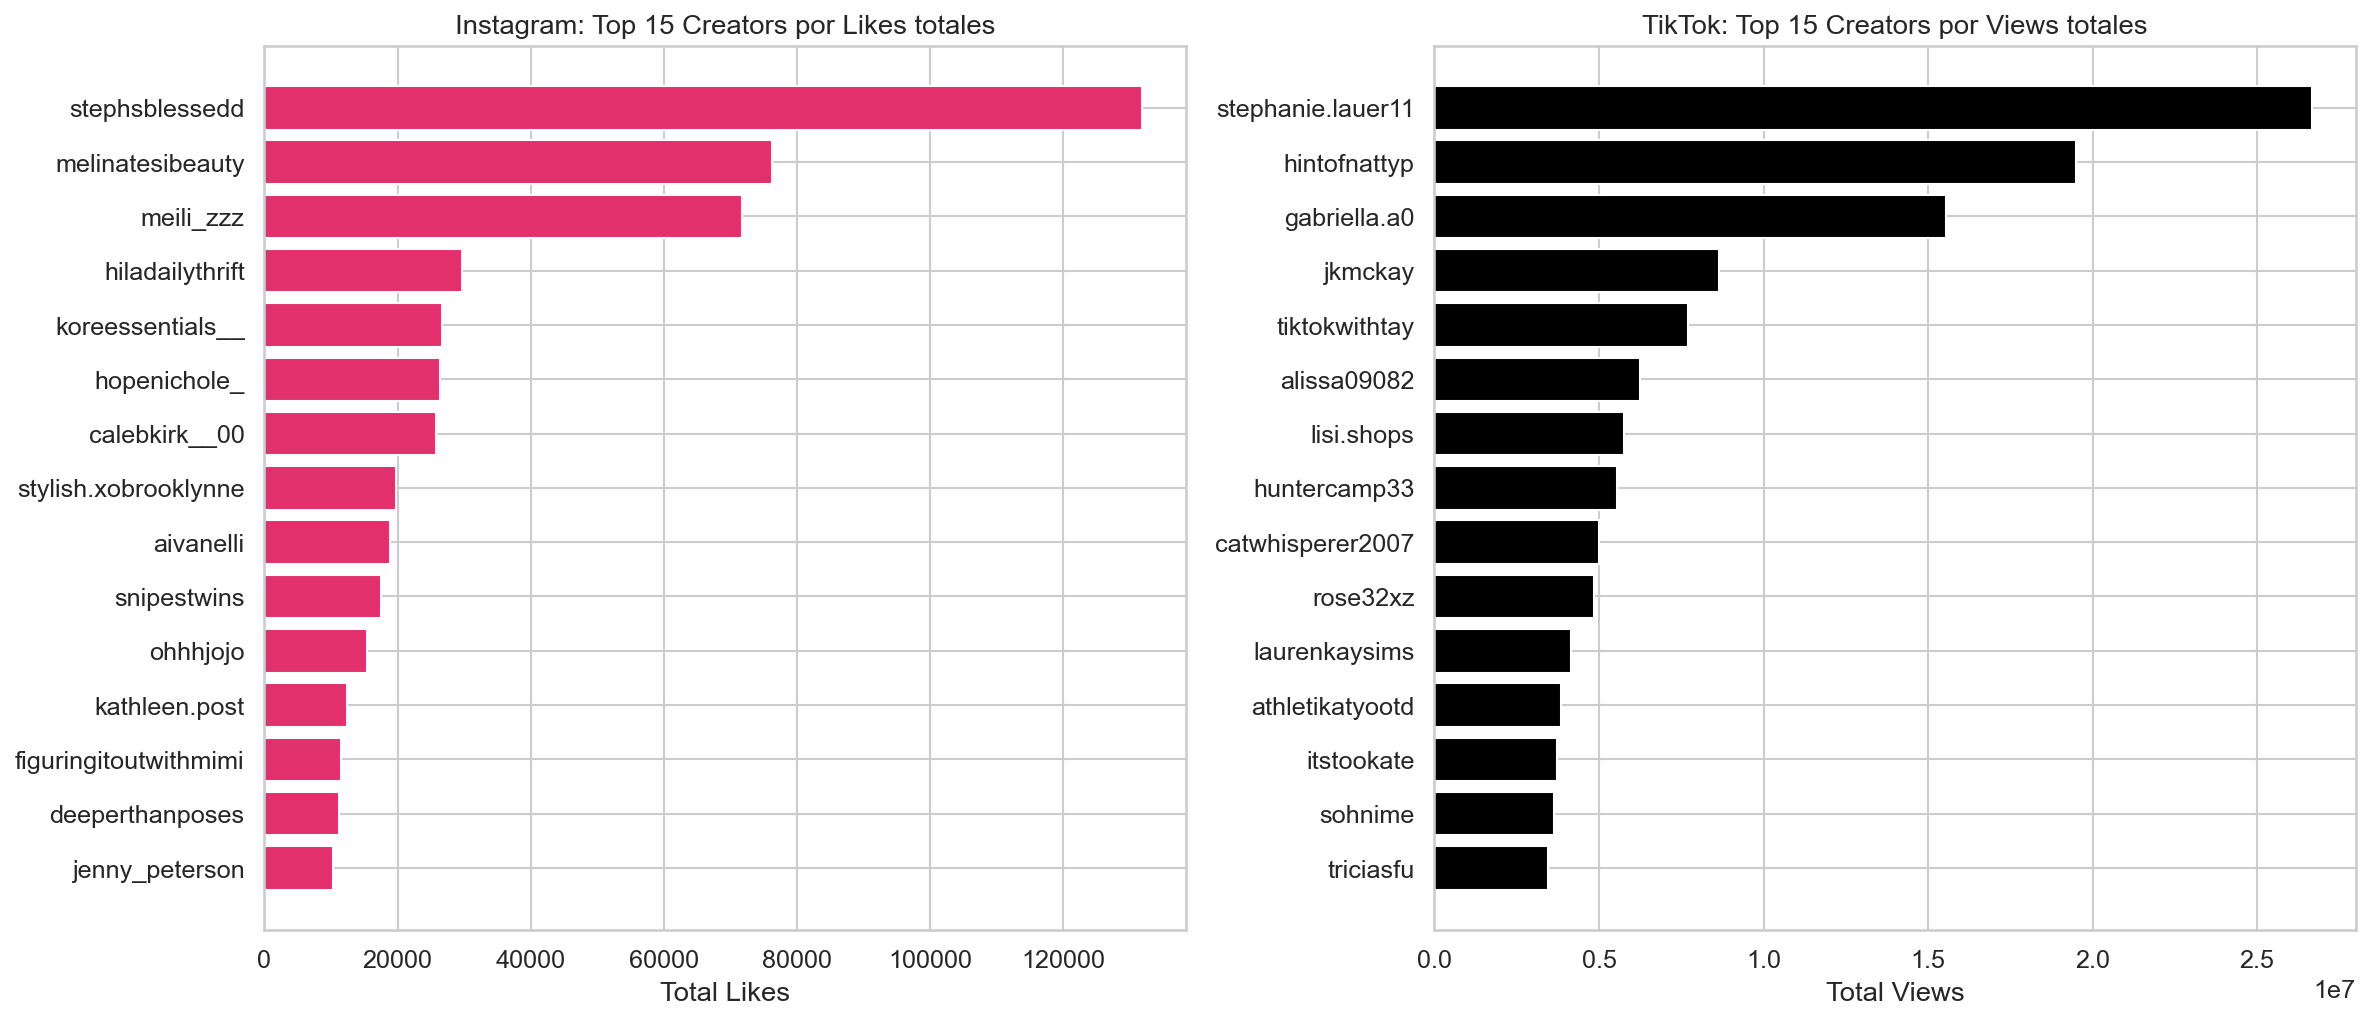

In [7]:
# Top creators por engagement
top_ig_creators = ig.groupby("ownerUsername").agg(
    n_posts=("url", "count"),
    total_likes=("likes", "sum"),
    total_comments=("comments", "sum"),
    avg_likes=("likes", "mean"),
).sort_values("total_likes", ascending=False).head(15)

top_tk_creators = tk.groupby("author").agg(
    n_videos=("id", "count"),
    total_views=("views", "sum"),
    total_likes=("likes", "sum"),
    avg_views=("views", "mean"),
).sort_values("total_views", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_ig_creators.index[::-1], top_ig_creators["total_likes"][::-1], color=PLATFORM_COLORS["instagram"])
axes[0].set_title("Instagram: Top 15 Creators por Likes totales")
axes[0].set_xlabel("Total Likes")

axes[1].barh(top_tk_creators.index[::-1], top_tk_creators["total_views"][::-1], color=PLATFORM_COLORS["tiktok"])
axes[1].set_title("TikTok: Top 15 Creators por Views totales")
axes[1].set_xlabel("Total Views")

plt.tight_layout()
save_fig(fig, "eda_top_creators")
plt.show()

## 5. Distribucion geografica

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/eda_distribucion_geografica.png


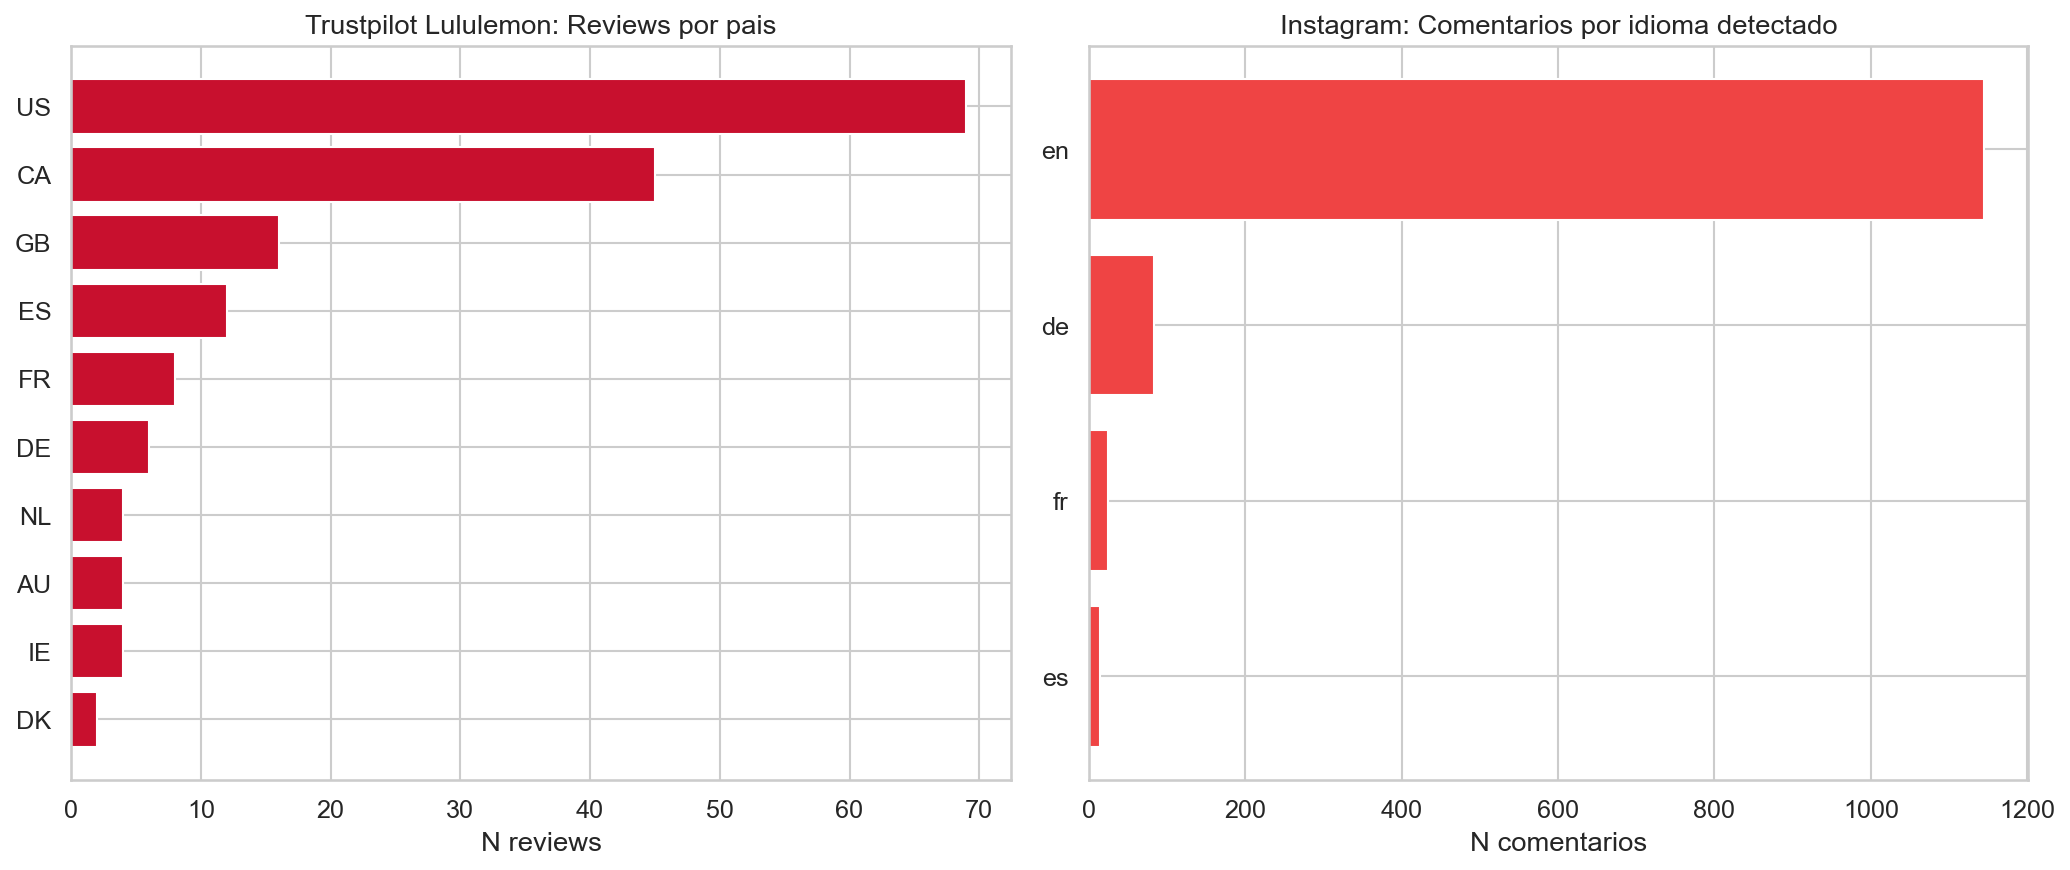

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Trustpilot Lululemon por pais
tp_lulu = tp[tp["brand"] == "Lululemon"]
country_counts = tp_lulu["country"].value_counts().head(10)
axes[0].barh(country_counts.index[::-1], country_counts.values[::-1], color=COLORS["lululemon_red"])
axes[0].set_title("Trustpilot Lululemon: Reviews por pais")
axes[0].set_xlabel("N reviews")

# Idiomas de comentarios IG
lang_counts = ig_com["lang"].value_counts().head(8)
axes[1].barh(lang_counts.index[::-1], lang_counts.values[::-1], color=COLORS["europe"])
axes[1].set_title("Instagram: Comentarios por idioma detectado")
axes[1].set_xlabel("N comentarios")

plt.tight_layout()
save_fig(fig, "eda_distribucion_geografica")
plt.show()

## 6. Correlaciones

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/eda_correlaciones.png


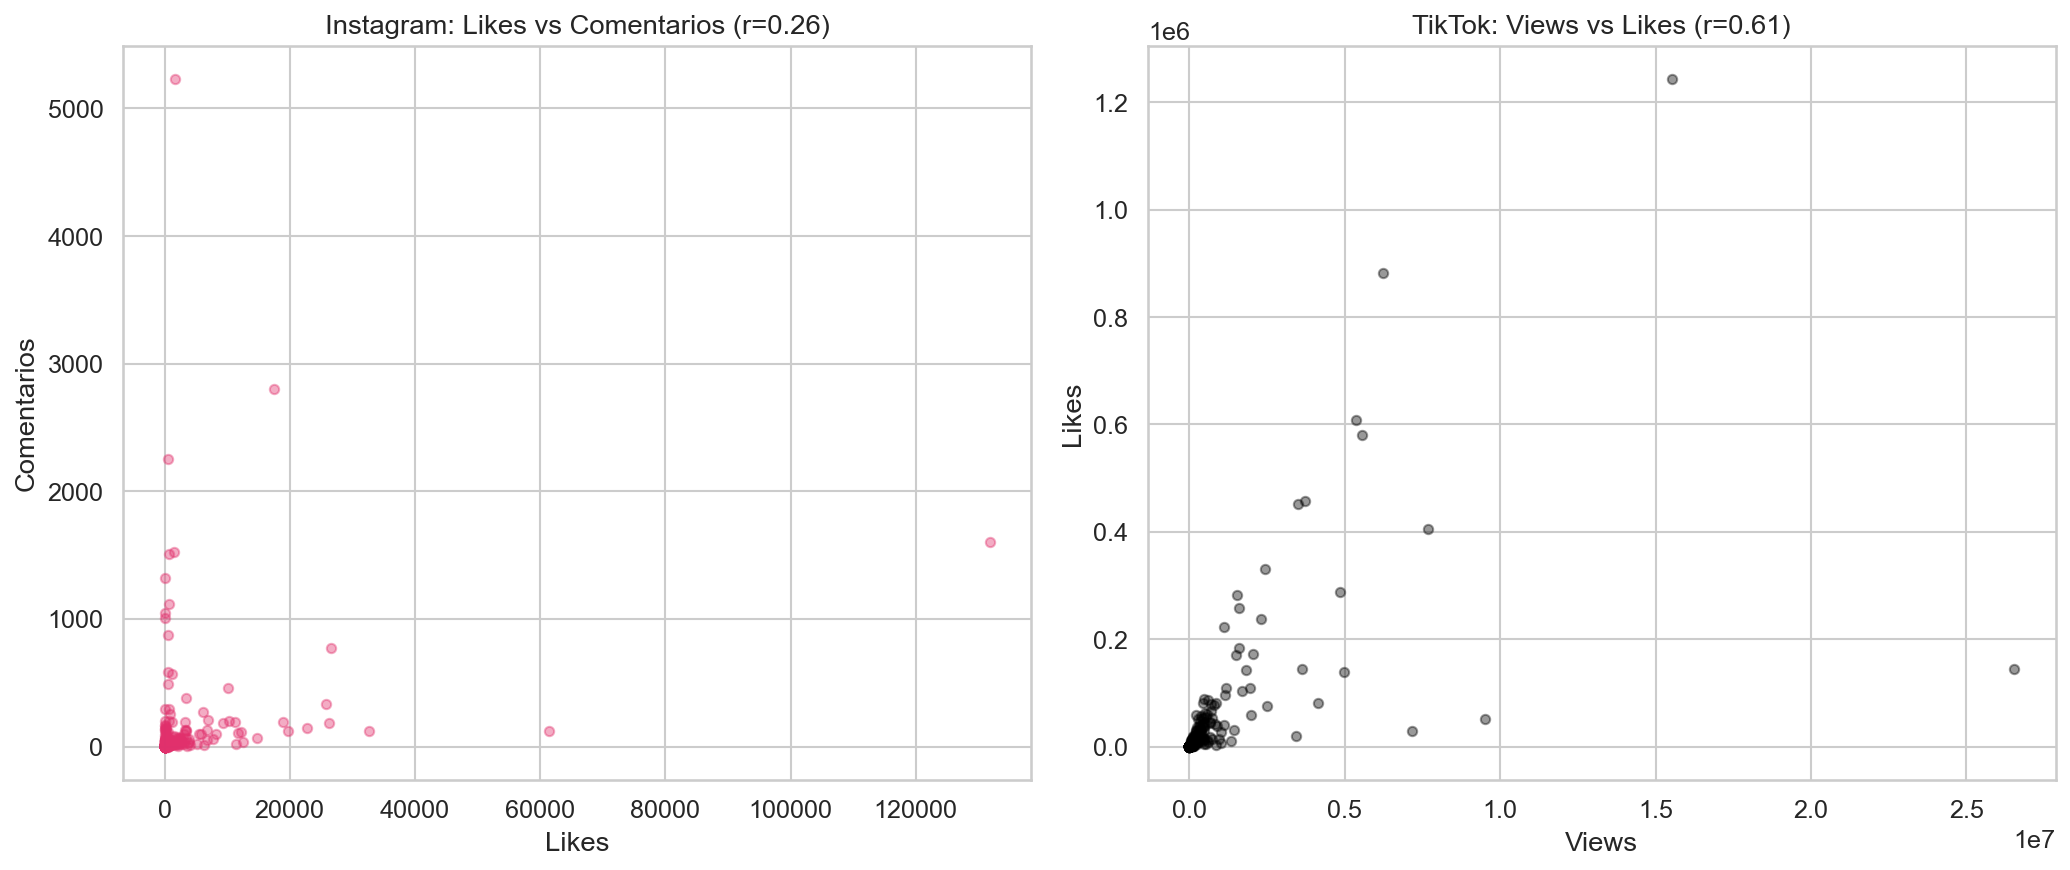

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# IG: likes vs comments
axes[0].scatter(ig["likes"], ig["comments"], alpha=0.4, s=20, color=PLATFORM_COLORS["instagram"])
axes[0].set_xlabel("Likes")
axes[0].set_ylabel("Comentarios")
axes[0].set_title(f"Instagram: Likes vs Comentarios (r={ig['likes'].corr(ig['comments']):.2f})")

# TikTok: views vs likes
axes[1].scatter(tk["views"], tk["likes"], alpha=0.4, s=20, color=PLATFORM_COLORS["tiktok"])
axes[1].set_xlabel("Views")
axes[1].set_ylabel("Likes")
axes[1].set_title(f"TikTok: Views vs Likes (r={tk['views'].corr(tk['likes']):.2f})")

plt.tight_layout()
save_fig(fig, "eda_correlaciones")
plt.show()

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/eda_heatmap_tiktok.png


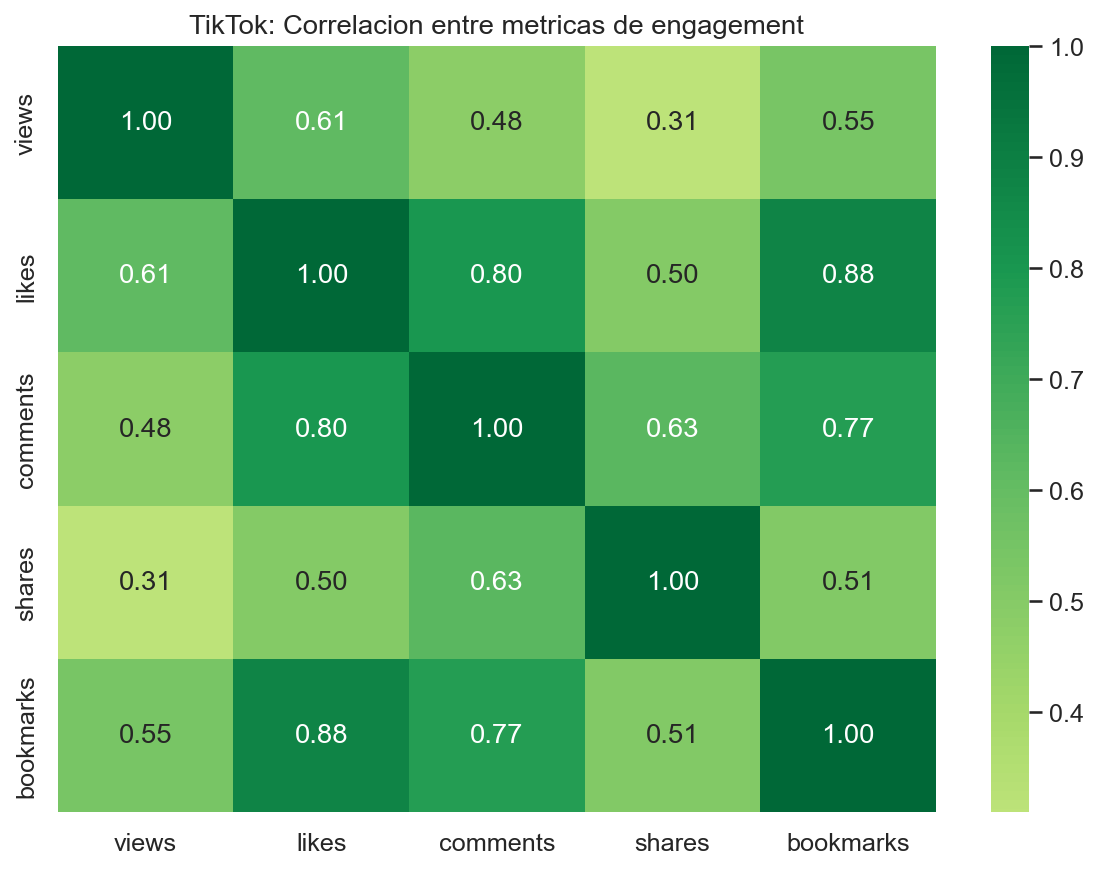

In [10]:
# Heatmap metricas TikTok
tk_metrics = tk[["views", "likes", "comments", "shares", "bookmarks"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(tk_metrics, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax)
ax.set_title("TikTok: Correlacion entre metricas de engagement")
plt.tight_layout()
save_fig(fig, "eda_heatmap_tiktok")
plt.show()

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/eda_tipo_contenido_ig.png


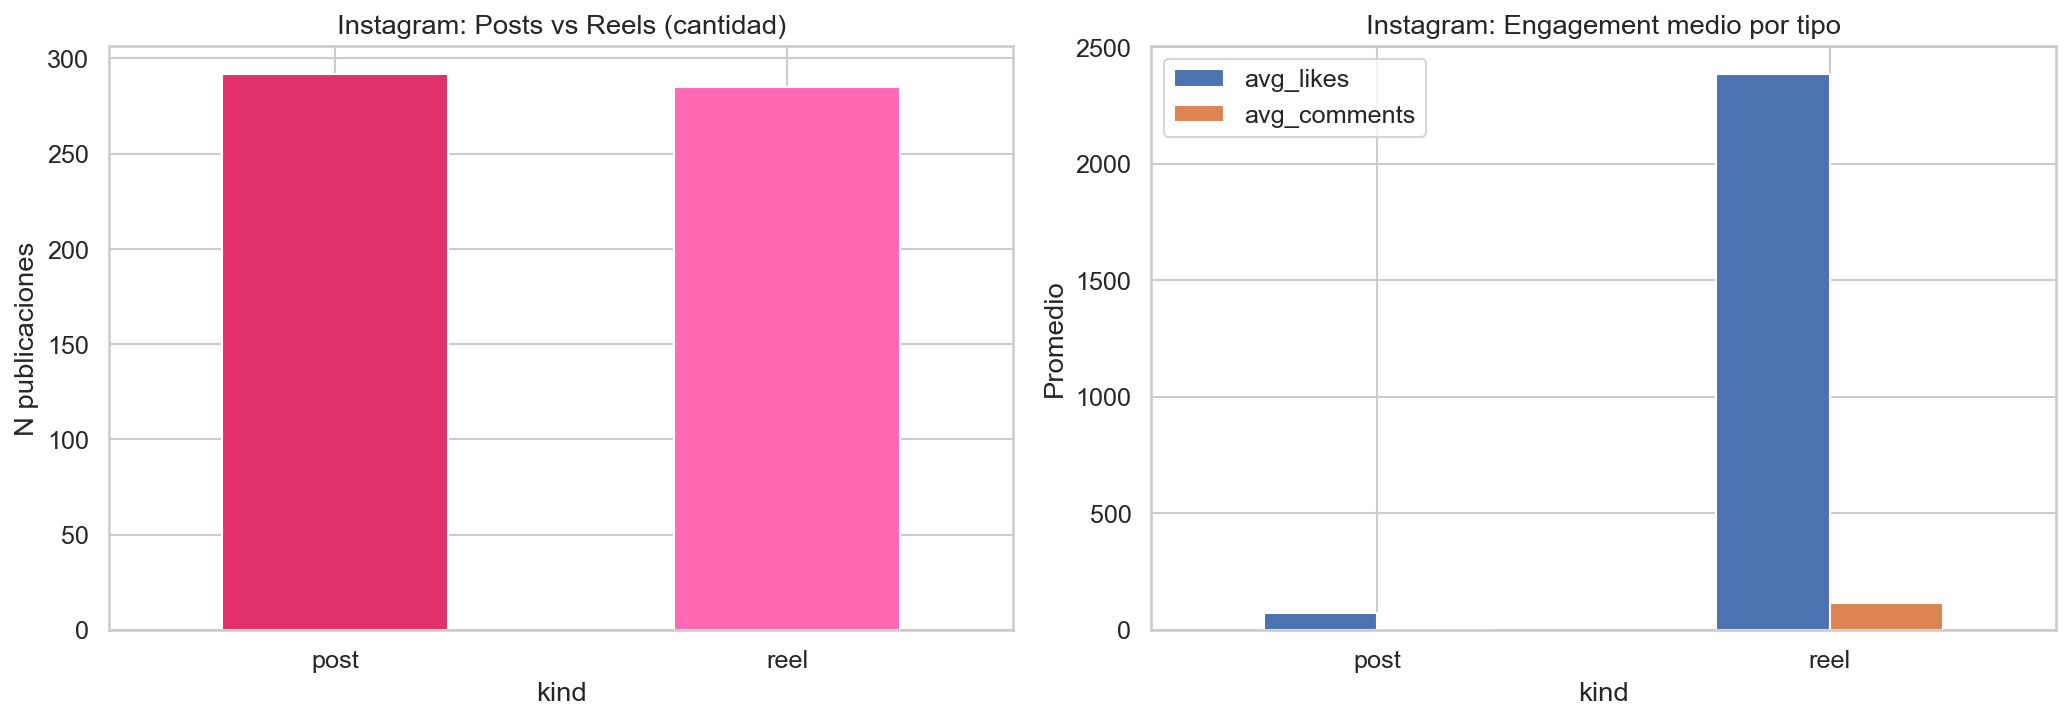

In [11]:
# Reels vs Posts en IG
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kind_stats = ig.groupby("kind").agg(
    count=("url", "count"),
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"),
)

kind_stats["count"].plot(kind="bar", ax=axes[0], color=[PLATFORM_COLORS["instagram"], "#FF69B4"])
axes[0].set_title("Instagram: Posts vs Reels (cantidad)")
axes[0].set_ylabel("N publicaciones")
axes[0].tick_params(axis="x", rotation=0)

kind_stats[["avg_likes", "avg_comments"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Instagram: Engagement medio por tipo")
axes[1].set_ylabel("Promedio")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
save_fig(fig, "eda_tipo_contenido_ig")
plt.show()

In [12]:
# Exportar tabla resumen
resumen_engagement = pd.DataFrame({
    "Metrica": ["IG Likes (media)", "IG Likes (mediana)", "IG Comments (media)",
                 "TK Views (media)", "TK Views (mediana)", "TK Likes (media)",
                 "TK Engagement Rate (media)", "TP Rating Lulu (media)", "TP Rating ALO (media)"],
    "Valor": [
        f"{ig['likes'].mean():,.0f}", f"{ig['likes'].median():,.0f}", f"{ig['comments'].mean():,.0f}",
        f"{tk['views'].mean():,.0f}", f"{tk['views'].median():,.0f}", f"{tk['likes'].mean():,.0f}",
        f"{tk['engagement_rate'].mean():.1f}%",
        f"{tp[tp['brand']=='Lululemon']['rating'].mean():.2f}",
        f"{tp[tp['brand']=='ALO Yoga']['rating'].mean():.2f}",
    ]
})

resumen_engagement.to_csv("../../outputs/tablas/eda_resumen_engagement.csv", index=False)
resumen_engagement

,Metrica,Valor
0,IG Likes (media),"1,217"
1,IG Likes (mediana),14
2,IG Comments (media),60
3,TK Views (media),"620,537"
4,TK Views (mediana),"74,544"
5,TK Likes (media),"37,093"
6,TK Engagement Rate (media),6.2%
7,TP Rating Lulu (media),1.56
8,TP Rating ALO (media),1.29
